In [1]:
# %pip install -r ../requirements.txt 

# Set up database

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.table import Table

# Reading (all)

In [4]:
query = """
        SELECT timestampdiff(MINUTE, ACTLOG_START, AO_FINISH) as TIME_READING, BREAK_TIME, FOCUS_LEVEL, TOTAL_COUNT, UNIT_COUNT
        FROM ACTIVITY
                natural join ACTIVITY_LOG
                natural join ACTIVITY_OUTPUT
                natural join KIT_COUNT
                natural join KIT_READING
        where (TRANSLATION is not null)
                and (ACTIVITY_ID=12)
                and (unit_count like 'pages');
        """
ps = pd.read_sql(query, engine)
ps.head()

,TIME_READING,BREAK_TIME,FOCUS_LEVEL,TOTAL_COUNT,UNIT_COUNT
0,45,3,medium,4.0,pages
1,76,0,high,3.0,pages
2,60,0,high,4.0,pages
3,79,0,high,7.0,pages
4,99,0,high,6.0,pages


/var/folders/20/3dpkl8y92xs2mr9bxxsnt9j40000gn/T/ipykernel_77275/2373113276.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot(


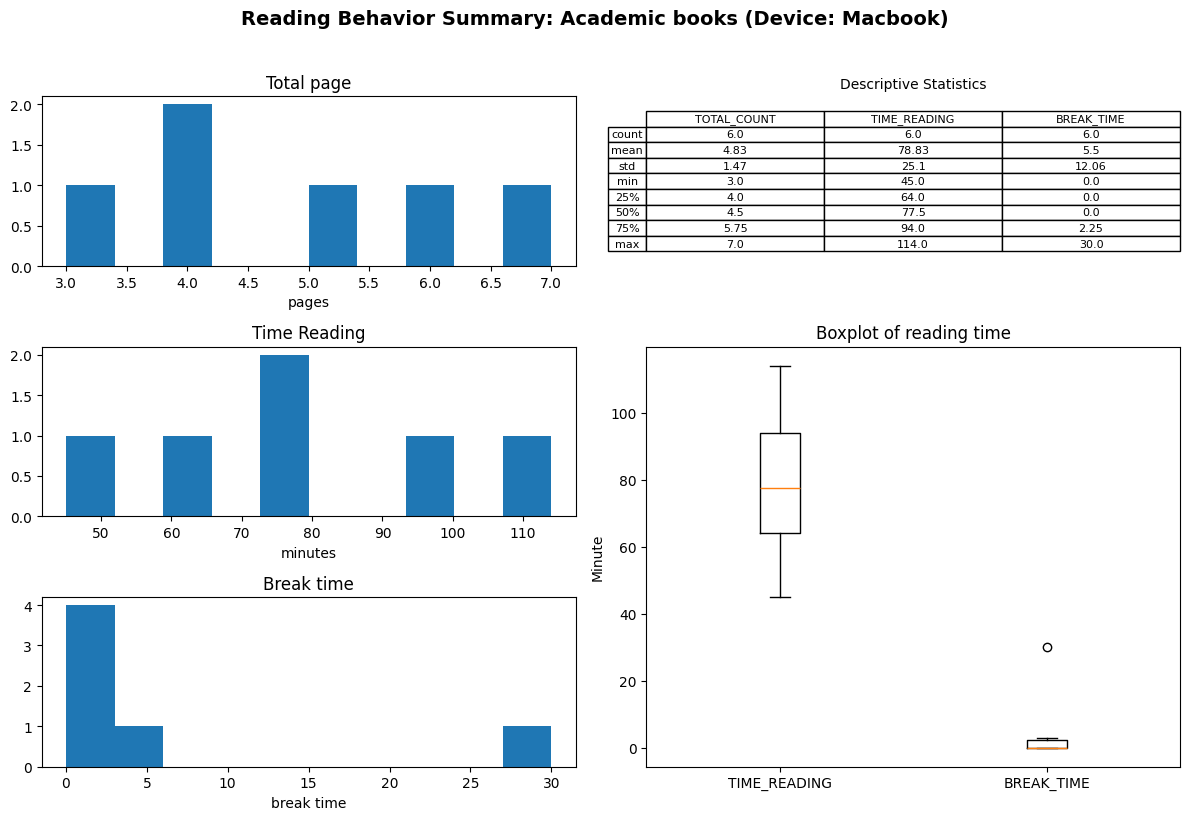

In [5]:
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(3, 2, figure=fig)

desc = ps[['TOTAL_COUNT', 'TIME_READING', 'BREAK_TIME']].describe().round(2)

ax_table = fig.add_subplot(gs[0, 1])
ax_table.axis('off')
table = ax_table.table(
    cellText=desc.values,
    rowLabels=desc.index,
    colLabels=desc.columns,
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1)
for key, cell in table.get_celld().items():
    cell.set_text_props(ha='center', va='center')
ax_table.set_title('Descriptive Statistics', fontsize=10)

# --- Plot 1 ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(ps['TOTAL_COUNT'])
ax1.set_xlabel("pages")
ax1.set_title("Total page")

# --- Plot 2 ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(ps['TIME_READING'])
ax2.set_xlabel("minutes")
ax2.set_title("Time Reading")

# --- Plot 3 ---
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(ps['BREAK_TIME'])
ax3.set_xlabel("break time")
ax3.set_title("Break time")

# --- Boxplot ---
ax4 = fig.add_subplot(gs[1:, 1])
ax4.boxplot(
    [ps['TIME_READING'].dropna(), ps['BREAK_TIME'].dropna()],
    labels=['TIME_READING', 'BREAK_TIME']
)
ax4.set_title('Boxplot of reading time')
ax4.set_ylabel('Minute')

fig.suptitle("Reading Behavior Summary: Academic books (Device: Macbook)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# Get means of both columns
means = ps[['TOTAL_COUNT', 'TIME_READING']].mean()
print(means[0], means[1])

4.833333333333333 78.83333333333333


/var/folders/20/3dpkl8y92xs2mr9bxxsnt9j40000gn/T/ipykernel_77275/1628905083.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(means[0], means[1])


In [7]:
def total_day(totalPages, hoursSpentPerDay):
    return (((totalPages * means[1])/means[0])/60)/hoursSpentPerDay

In [8]:
print(total_day(totalPages=121, hoursSpentPerDay=5))

6.578505747126437


/var/folders/20/3dpkl8y92xs2mr9bxxsnt9j40000gn/T/ipykernel_77275/966302175.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (((totalPages * means[1])/means[0])/60)/hoursSpentPerDay
